In [12]:
# --- 1. ИМПОРТ БИБЛИОТЕК И НАСТРОЙКИ ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import os
import time
from datetime import datetime

# Scikit-learn импорты
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.inspection import permutation_importance

# Настройки
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("Библиотеки загружены")

Библиотеки загружены


In [13]:
# --- 2. ФУНКЦИИ ДЛЯ РАБОТЫ С ДАННЫМИ ---

def load_data(filepath):
    """Загрузка данных из CSV файла"""
    df = pd.read_csv(filepath)
    print(f"Данные загружены: {df.shape[0]} строк, {df.shape[1]} столбцов")
    return df

def basic_eda(df):
    """Базовый анализ данных"""
    print("\n=== БАЗОВЫЙ АНАЛИЗ ДАННЫХ ===")
    
    # Первые строки
    print("\nПервые 5 строк:")
    display(df.head())
    
    # Информация о типах данных
    print("\nИнформация о типах данных:")
    print(df.info())
    
    # Распределение целевой переменной
    print("\nРаспределение целевой переменной (target):")
    target_dist = df['target'].value_counts(normalize=True)
    display(target_dist)
    
    # Визуализация распределения
    plt.figure(figsize=(8, 6))
    target_dist.plot(kind='bar')
    plt.title('Распределение классов')
    plt.xlabel('Класс')
    plt.ylabel('Доля')
    plt.tight_layout()
    plt.savefig('artifacts/figures/target_distribution.png')
    plt.show()
    
    return df

def prepare_data(df):
    """Подготовка данных для обучения"""
    print("\n=== ПОДГОТОВКА ДАННЫХ ===")
    
    # Удаляем ненужные столбцы
    if 'id' in df.columns:
        df = df.drop('id', axis=1)
        print("Столбец 'id' удален")
    
    # Разделяем на признаки и целевую переменную
    X = df.drop('target', axis=1)
    y = df['target']
    
    print(f"Признаки (X): {X.shape}")
    print(f"Целевая переменная (y): {y.shape}")
    
    return X, y

def split_data(X, y, test_size=0.2, random_state=42):
    """Разделение данных на train/test"""
    print(f"\n=== РАЗДЕЛЕНИЕ ДАННЫХ ===")
    print(f"test_size={test_size}, random_state={random_state}")
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=y
    )
    
    print(f"Train: {X_train.shape}, Test: {X_test.shape}")
    
    return X_train, X_test, y_train, y_test

In [14]:
# --- 3. ФУНКЦИИ ДЛЯ МЕТРИК И ОЦЕНКИ ---

def calculate_metrics(y_true, y_pred, y_proba=None, model_name=""):
    """Вычисление метрик для модели"""
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred)
    }
    
    if y_proba is not None and len(np.unique(y_true)) == 2:
        metrics['roc_auc'] = roc_auc_score(y_true, y_proba)
    else:
        metrics['roc_auc'] = None
    
    return metrics

def print_metrics_table(metrics_list):
    """Вывод таблицы с метриками"""
    df = pd.DataFrame(metrics_list)
    print("\n" + "="*60)
    print("ТАБЛИЦА МЕТРИК ВСЕХ МОДЕЛЕЙ")
    print("="*60)
    display(df.sort_values('accuracy', ascending=False))
    return df

def plot_roc_curves(models_dict, X_test, y_test):
    """Построение ROC-кривых для всех моделей"""
    plt.figure(figsize=(10, 8))
    
    for name, model in models_dict.items():
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc = roc_auc_score(y_test, y_proba)
            plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('artifacts/figures/roc_curves.png')
    plt.show()

def plot_confusion_matrix(model, X_test, y_test, model_name):
    """Построение матрицы ошибок"""
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'artifacts/figures/confusion_matrix_{model_name}.png')
    plt.show()

In [15]:
# --- 4. БАЗОВЫЕ МОДЕЛИ ---

def create_baseline_models(X_train, y_train, X_test, y_test):
    """Создание и оценка baseline моделей"""
    print("\n=== БАЗОВЫЕ МОДЕЛИ ===")
    
    models = {}
    metrics_list = []
    
    # 1. Dummy Classifier
    print("\n1. Dummy Classifier")
    dummy = DummyClassifier(strategy='stratified', random_state=42)
    dummy.fit(X_train, y_train)
    
    y_pred = dummy.predict(X_test)
    y_proba = dummy.predict_proba(X_test)[:, 1] if hasattr(dummy, 'predict_proba') else None
    
    metrics = calculate_metrics(y_test, y_pred, y_proba, "Dummy")
    metrics_list.append(metrics)
    models['Dummy'] = dummy
    
    print(f"Accuracy: {metrics['accuracy']:.4f}, F1: {metrics['f1']:.4f}")
    
    # 2. Logistic Regression
    print("\n2. Logistic Regression")
    lr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(random_state=42, max_iter=1000))
    ])
    lr_pipeline.fit(X_train, y_train)
    
    y_pred = lr_pipeline.predict(X_test)
    y_proba = lr_pipeline.predict_proba(X_test)[:, 1]
    
    metrics = calculate_metrics(y_test, y_pred, y_proba, "LogisticRegression")
    metrics_list.append(metrics)
    models['LogisticRegression'] = lr_pipeline
    
    print(f"Accuracy: {metrics['accuracy']:.4f}, F1: {metrics['f1']:.4f}")
    
    return models, metrics_list

In [16]:
# --- 5. ДЕРЕВО РЕШЕНИЙ ---

def train_decision_tree(X_train, y_train, X_test, y_test):
    """Обучение и оптимизация дерева решений"""
    print("\n=== ДЕРЕВО РЕШЕНИЙ ===")
    
    # Базовая модель
    tree = DecisionTreeClassifier(random_state=42)
    
    # Параметры для GridSearch
    param_grid = {
        'max_depth': [3, 5, 7, 10],
        'min_samples_leaf': [1, 2, 5],
        'min_samples_split': [2, 5, 10],
        'criterion': ['gini', 'entropy']
    }
    
    print("Поиск лучших параметров...")
    grid_search = GridSearchCV(
        tree, param_grid, cv=3, scoring='roc_auc', n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший CV ROC-AUC: {grid_search.best_score_:.4f}")
    
    # Лучшая модель
    best_tree = grid_search.best_estimator_
    y_pred = best_tree.predict(X_test)
    y_proba = best_tree.predict_proba(X_test)[:, 1]
    
    metrics = calculate_metrics(y_test, y_pred, y_proba, "DecisionTree")
    print(f"Test Accuracy: {metrics['accuracy']:.4f}, F1: {metrics['f1']:.4f}")
    
    # Визуализация
    plot_confusion_matrix(best_tree, X_test, y_test, "DecisionTree")
    
    return best_tree, metrics

In [18]:
# --- 6. RANDOM FOREST  ---

def train_random_forest(X_train, y_train, X_test, y_test):
    """Обучение Random Forest"""
    print("\n=== RANDOM FOREST ===")
    
    # Ускоренная версия Random Forest
    rf = RandomForestClassifier(
        n_estimators=50,  # Меньше деревьев для скорости
        random_state=42,
        n_jobs=-1
    )
    
    # Ограниченная сетка параметров для скорости
    param_grid = {
        'max_depth': [5, 10, 15],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 'log2']
    }
    
    print("Быстрый поиск параметров...")
    grid_search = GridSearchCV(
        rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший CV ROC-AUC: {grid_search.best_score_:.4f}")
    
    # Финальное обучение с лучшими параметрами
    best_rf = grid_search.best_estimator_
    
    # Переобучаем с большим количеством деревьев, но с теми же параметрами
    final_rf = RandomForestClassifier(
        **grid_search.best_params_,
        n_estimators=100,  # Увеличиваем для финальной модели
        random_state=42,
        n_jobs=-1
    )
    final_rf.fit(X_train, y_train)
    
    y_pred = final_rf.predict(X_test)
    y_proba = final_rf.predict_proba(X_test)[:, 1]
    
    metrics = calculate_metrics(y_test, y_pred, y_proba, "RandomForest")
    print(f"Test Accuracy: {metrics['accuracy']:.4f}, F1: {metrics['f1']:.4f}")
    
    # Визуализация
    plot_confusion_matrix(final_rf, X_test, y_test, "RandomForest")
    
    return final_rf, metrics

In [19]:
# --- 7. GRADIENT BOOSTING ---

def train_gradient_boosting(X_train, y_train, X_test, y_test):
    """Обучение Gradient Boosting"""
    print("\n=== GRADIENT BOOSTING ===")
    
    gb = GradientBoostingClassifier(random_state=42)
    
    # Параметры для GridSearch
    param_grid = {
        'n_estimators': [50, 100],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5]
    }
    
    print("Поиск лучших параметров...")
    grid_search = GridSearchCV(
        gb, param_grid, cv=3, scoring='roc_auc', n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший CV ROC-AUC: {grid_search.best_score_:.4f}")
    
    # Лучшая модель
    best_gb = grid_search.best_estimator_
    y_pred = best_gb.predict(X_test)
    y_proba = best_gb.predict_proba(X_test)[:, 1]
    
    metrics = calculate_metrics(y_test, y_pred, y_proba, "GradientBoosting")
    print(f"Test Accuracy: {metrics['accuracy']:.4f}, F1: {metrics['f1']:.4f}")
    
    # Визуализация
    plot_confusion_matrix(best_gb, X_test, y_test, "GradientBoosting")
    
    return best_gb, metrics

In [20]:
# --- 8. СТЕКИНГ  ---

def train_stacking_model(models_dict, X_train, y_train, X_test, y_test):
    """Создание стекинговой модели"""
    print("\n=== STACKING MODEL ===")
    
    # Создаем список базовых моделей для стекинга
    estimators = []
    for name, model in models_dict.items():
        if name not in ['Dummy', 'Stacking']:  # Исключаем dummy и саму stacking
            estimators.append((name, model))
    
    if len(estimators) < 2:
        print("Недостаточно моделей для стекинга")
        return None, None
    
    # Создаем stacking модель
    stacking = StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(),
        cv=5
    )
    
    print(f"Обучение стекинга на {len(estimators)} моделях...")
    stacking.fit(X_train, y_train)
    
    y_pred = stacking.predict(X_test)
    y_proba = stacking.predict_proba(X_test)[:, 1]
    
    metrics = calculate_metrics(y_test, y_pred, y_proba, "Stacking")
    print(f"Test Accuracy: {metrics['accuracy']:.4f}, F1: {metrics['f1']:.4f}")
    
    return stacking, metrics

In [21]:
# --- 9. АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ ---

def analyze_feature_importance(model, X_test, y_test, model_name, top_n=10):
    """Анализ важности признаков"""
    print(f"\n=== ВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ {model_name} ===")
    
    # Permutation importance
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=5,
        random_state=42,
        scoring='roc_auc'
    )
    
    # Создаем DataFrame
    importances = pd.DataFrame({
        'feature': X_test.columns,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std
    }).sort_values('importance_mean', ascending=False)
    
    print(f"Топ-{top_n} важных признаков:")
    display(importances.head(top_n))
    
    # Визуализация
    plt.figure(figsize=(10, 6))
    top_features = importances.head(top_n)
    bars = plt.barh(top_features['feature'], top_features['importance_mean'])
    plt.xlabel('Permutation Importance')
    plt.title(f'Top {top_n} Features - {model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'artifacts/figures/feature_importance_{model_name}.png')
    plt.show()
    
    return importances

In [22]:
# --- 10. СОХРАНЕНИЕ АРТЕФАКТОВ ---

def save_artifacts(all_models, all_metrics, best_model_name):
    """Сохранение всех артефактов эксперимента"""
    print("\n=== СОХРАНЕНИЕ АРТЕФАКТОВ ===")
    
    # Создаем папки
    os.makedirs('artifacts/figures', exist_ok=True)
    
    # 1. Сохраняем метрики
    metrics_dict = {m['model']: m for m in all_metrics}
    with open('artifacts/metrics_test.json', 'w') as f:
        json.dump(metrics_dict, f, indent=2)
    
    # 2. Сохраняем лучшую модель
    if best_model_name in all_models:
        joblib.dump(all_models[best_model_name], 'artifacts/best_model.joblib')
    
    # 3. Сохраняем метаданные
    best_model_meta = {
        'best_model': best_model_name,
        'best_metrics': metrics_dict.get(best_model_name, {}),
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
    
    with open('artifacts/best_model_meta.json', 'w') as f:
        json.dump(best_model_meta, f, indent=2)
    
    print("✓ Артефакты сохранены в папку artifacts/")

Данные загружены: 12000 строк, 30 столбцов

=== БАЗОВЫЙ АНАЛИЗ ДАННЫХ ===

Первые 5 строк:


,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,num10,num11,num12,num13,num14,num15,num16,num17,num18,num19,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,1,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,-0.417059,0.799265,-1.484333,1.645497,1.519635,-1.259234,3.095407,-0.683026,1.152902,0.150213,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33,0
1,2,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,-1.122641,-0.313923,-1.298557,4.402595,0.552276,-0.006363,-0.729615,1.072416,2.654621,1.955462,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102,1
2,3,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,-0.477243,-0.839634,0.413097,3.277826,0.930134,1.219061,0.682610,2.587941,2.422656,-0.573642,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3,0
3,4,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,1.149337,0.604785,-0.090661,-0.797300,-0.201065,0.217428,4.598689,1.145859,-2.446382,1.809714,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50,0
4,5,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,1.113718,1.171501,-0.143172,3.479856,-1.095421,-1.402469,1.620111,-0.956420,-0.757656,0.289182,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81,0



Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 n

target
0    0.676583
1    0.323417
Name: proportion, dtype: float64

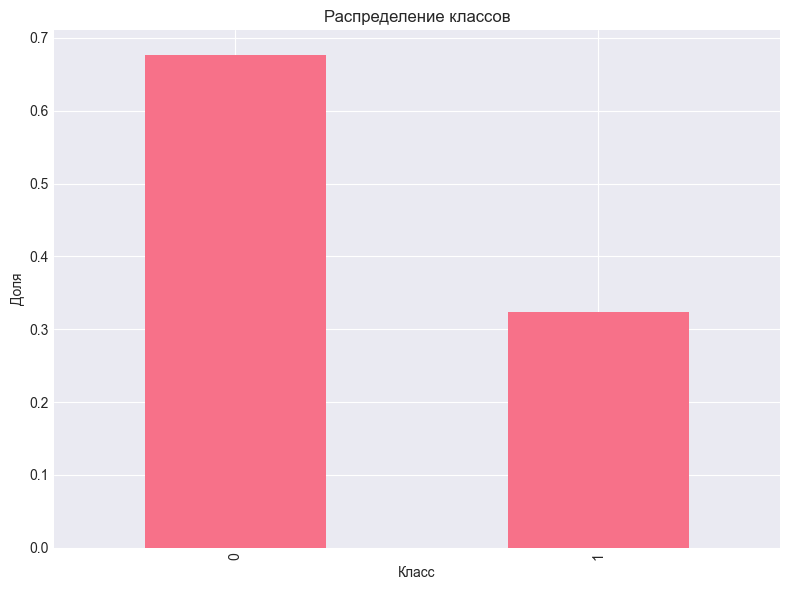


=== ПОДГОТОВКА ДАННЫХ ===
Столбец 'id' удален
Признаки (X): (12000, 28)
Целевая переменная (y): (12000,)

=== РАЗДЕЛЕНИЕ ДАННЫХ ===
test_size=0.2, random_state=42
Train: (9600, 28), Test: (2400, 28)

=== БАЗОВЫЕ МОДЕЛИ ===

1. Dummy Classifier
Accuracy: 0.5754, F1: 0.3405

2. Logistic Regression
Accuracy: 0.8275, F1: 0.7076

=== ДЕРЕВО РЕШЕНИЙ ===
Поиск лучших параметров...
Лучшие параметры: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}
Лучший CV ROC-AUC: 0.8944
Test Accuracy: 0.8596, F1: 0.7655


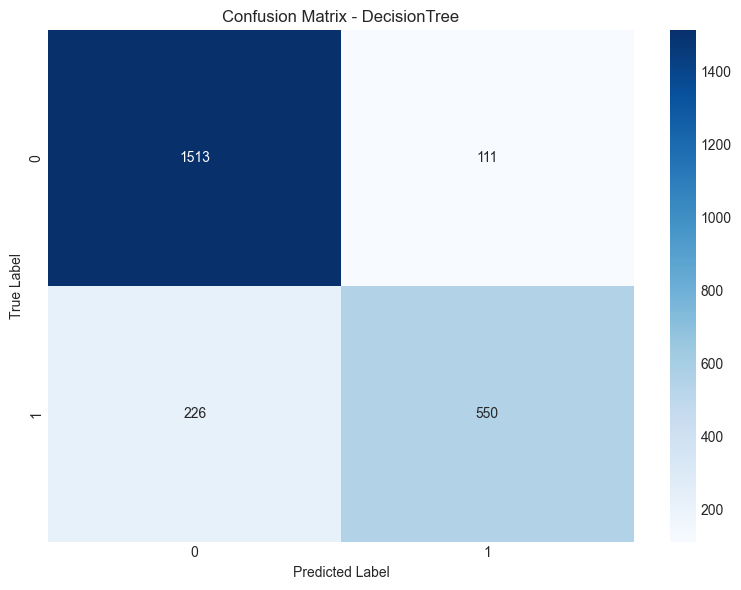


=== RANDOM FOREST ===
Быстрый поиск параметров...
Лучшие параметры: {'max_depth': 15, 'max_features': 'log2', 'min_samples_split': 2}
Лучший CV ROC-AUC: 0.9655
Test Accuracy: 0.9213, F1: 0.8705


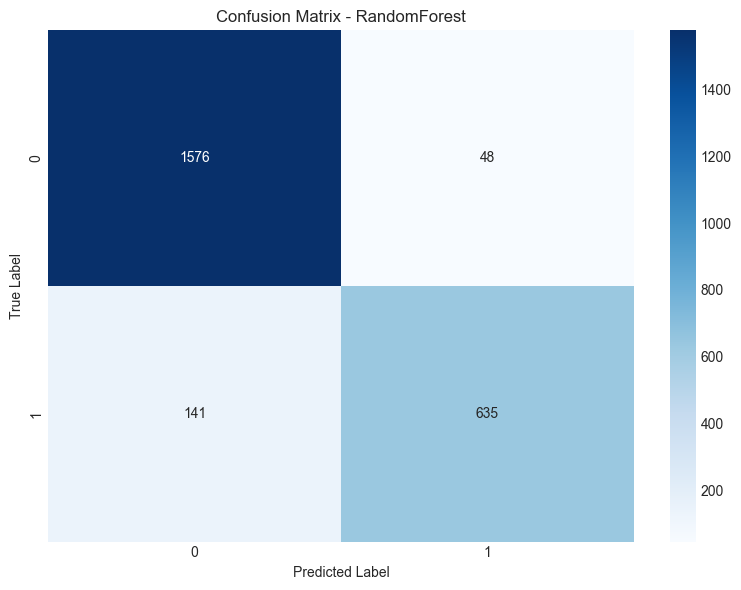


=== GRADIENT BOOSTING ===
Поиск лучших параметров...
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Лучший CV ROC-AUC: 0.9678
Test Accuracy: 0.9192, F1: 0.8686


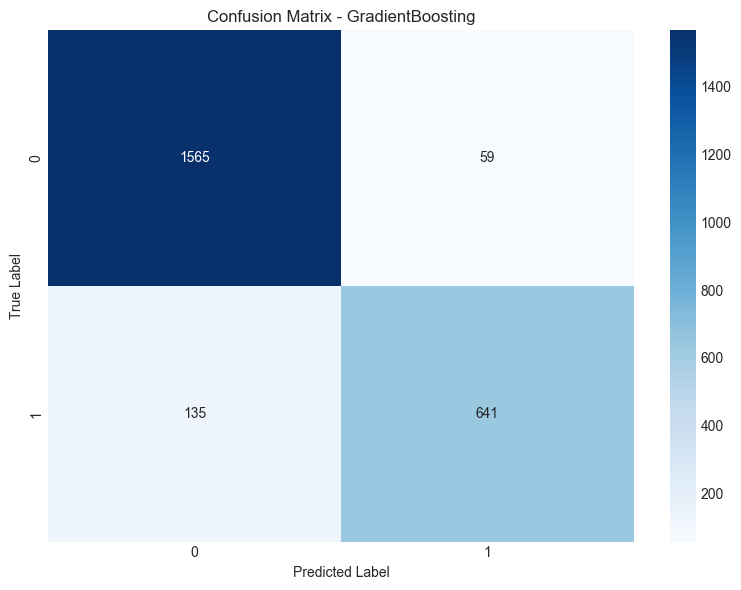


=== STACKING MODEL ===
Обучение стекинга на 4 моделях...
Test Accuracy: 0.9275, F1: 0.8857

ТАБЛИЦА МЕТРИК ВСЕХ МОДЕЛЕЙ


,model,accuracy,f1,roc_auc
5,Stacking,0.927500,0.885677,0.967670
3,RandomForest,0.921250,0.870459,0.964878
4,GradientBoosting,0.919167,0.868564,0.964002
2,DecisionTree,0.859583,0.765484,0.893606
1,LogisticRegression,0.827500,0.707627,0.874691
0,Dummy,0.575417,0.340453,0.513671


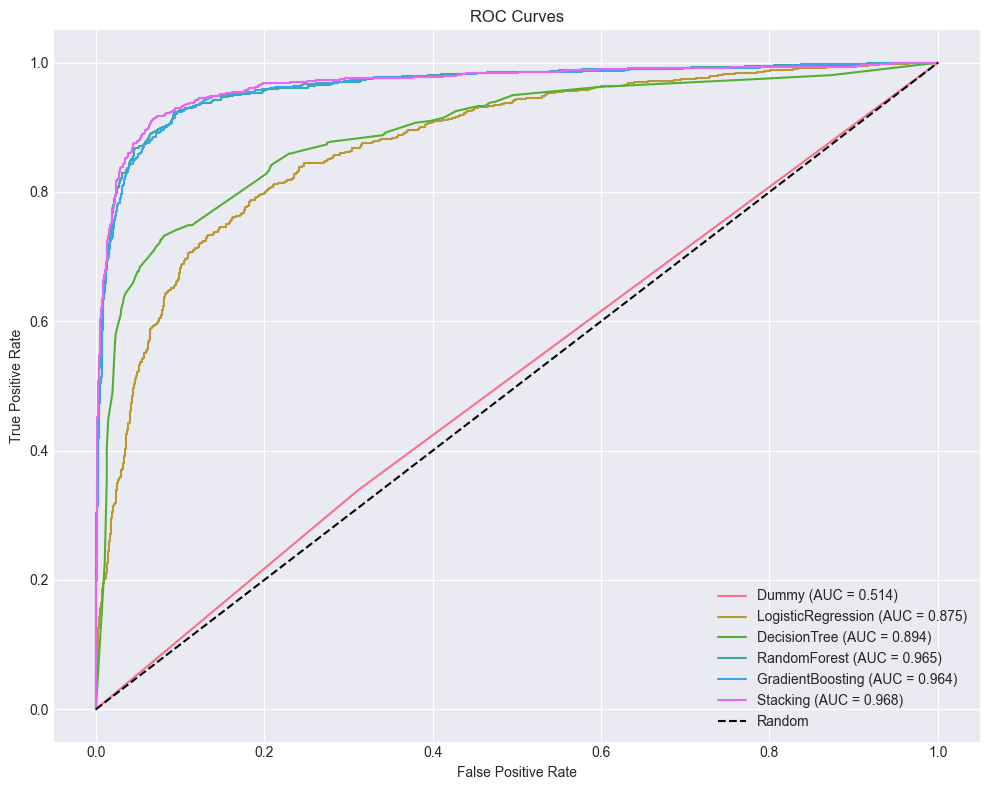


ЛУЧШАЯ МОДЕЛЬ: Stacking
Accuracy: 0.9275, F1: 0.8857

=== ВАЖНОСТЬ ПРИЗНАКОВ ДЛЯ Stacking ===
Топ-10 важных признаков:


,feature,importance_mean,importance_std
17,num18,0.060663,0.005068
18,num19,0.056824,0.002782
6,num07,0.029106,0.001182
3,num04,0.013108,0.000747
19,num20,0.011204,0.001022
23,num24,0.010105,0.000727
0,num01,0.009939,0.000944
21,num22,0.007585,0.000700
13,num14,0.007568,0.000660
7,num08,0.005932,0.000750


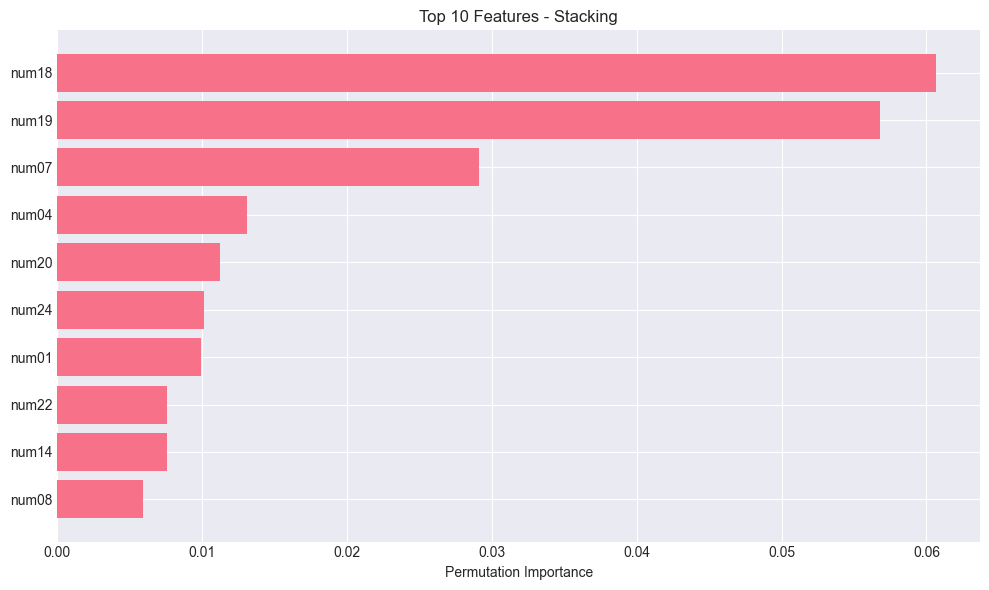


=== СОХРАНЕНИЕ АРТЕФАКТОВ ===
✓ Артефакты сохранены в папку artifacts/


In [24]:
# --- 11. ОСНОВНОЙ ПРОЦЕСС ВЫПОЛНЕНИЯ ---

def main():
    """Основной процесс выполнения задания"""
    
    
    # Шаг 1: Загрузка данных
    df = load_data('S06-hw-dataset-01.csv')
    df = basic_eda(df)
    
    # Шаг 2: Подготовка данных
    X, y = prepare_data(df)
    X_train, X_test, y_train, y_test = split_data(X, y)
    
    # Словарь для хранения всех моделей
    all_models = {}
    all_metrics = []
    
    # Шаг 3: Baseline модели
    baseline_models, baseline_metrics = create_baseline_models(
        X_train, y_train, X_test, y_test
    )
    all_models.update(baseline_models)
    all_metrics.extend(baseline_metrics)
    
    # Шаг 4: Дерево решений
    tree_model, tree_metrics = train_decision_tree(
        X_train, y_train, X_test, y_test
    )
    all_models['DecisionTree'] = tree_model
    all_metrics.append(tree_metrics)
    
    # Шаг 5: Random Forest
    rf_model, rf_metrics = train_random_forest(
        X_train, y_train, X_test, y_test
    )
    all_models['RandomForest'] = rf_model
    all_metrics.append(rf_metrics)
    
    # Шаг 6: Gradient Boosting
    gb_model, gb_metrics = train_gradient_boosting(
        X_train, y_train, X_test, y_test
    )
    all_models['GradientBoosting'] = gb_model
    all_metrics.append(gb_metrics)
    
    # Шаг 7: Stacking (опционально)
    stacking_model, stacking_metrics = train_stacking_model(
        all_models, X_train, y_train, X_test, y_test
    )
    if stacking_model:
        all_models['Stacking'] = stacking_model
        all_metrics.append(stacking_metrics)
    
    # Шаг 8: Сравнение всех моделей
    metrics_df = print_metrics_table(all_metrics)
    
    # ROC-кривые
    plot_roc_curves(all_models, X_test, y_test)
    
    # Шаг 9: Определение лучшей модели
    best_model_row = metrics_df.loc[metrics_df['accuracy'].idxmax()]
    best_model_name = best_model_row['model']
    print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
    print(f"Accuracy: {best_model_row['accuracy']:.4f}, F1: {best_model_row['f1']:.4f}")
    
    # Шаг 10: Анализ важности признаков для лучшей модели
    if best_model_name in all_models:
        feature_importance = analyze_feature_importance(
            all_models[best_model_name], 
            X_test, y_test, 
            best_model_name
        )
    
    # Шаг 11: Сохранение артефактов
    save_artifacts(all_models, all_metrics, best_model_name)
    

# Запуск основной программы
if __name__ == "__main__":
    main()